# Sound augmentation Trial

[A Python library for audio data augmentation. Inspired by albumentations]
(https://github.com/iver56/audiomentations)

[Fast audio data augmentation in PyTorch](https://github.com/asteroid-team/torch-audiomentations)

[visual augment](https://phrasenmaeher-audio-transformat-visualize-transformation-5s1n4t.streamlit.app/)

In [36]:
from audiomentations import (Compose, AddGaussianNoise, TimeStretch, 
                             AddGaussianSNR, AddGaussianNoise, PitchShift,
                             Shift, AddBackgroundNoise, PolarityInversion,
                             Reverse)

import numpy as np

import IPython
import librosa
import librosa.display
import sys
import os
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('..'))

# Local imports from current directory - auto reload.
# Any changes you make to train.py will appear automatically.
%load_ext autoreload
%autoreload 2

from dataprocess.util.data_process import read_snd_file

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
DATA_DIR = '../data/sound/grasshopper-raw-ds'
BG_DIR = '../data/sound/background_sounds/mono_5s/'

In [7]:
# Generate 2 seconds of dummy audio for the sake of example
d1, sr1 = librosa.load(f'{DATA_DIR}/gh-4/gh-4_mono_44k_denoised_1.wav', sr=None, mono=False)

print(f'sameple rate: {sr1}')

IPython.display.Audio(data=d1, rate=sr1)

sameple rate: 44100


In [8]:

#augment1 = AddGaussianSNR(min_snr_in_db=60.0, max_snr_in_db=80.0, p=1.0)
augment1 = AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.010, p=1.0)
# Augment/transform/perturb the audio data
aug_d1 = augment1(samples=d1, sample_rate=sr1)

IPython.display.Audio(data=aug_d1, rate=sr1)

In [33]:
# plot_sigx2(
#     d1,
#     aug_d1,
#     name1="Origin",
#     name2="Augment",
#     SR=sr1,
#     CMAP="magma",
#     cwt=True,
#     db_range=30,
# )

def plot_spectro_two(d1, d2, sr):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
        # And compute the spectrogram magnitude and phase
    S_full1, phase1 = librosa.magphase(librosa.stft(d1))
    img = librosa.display.specshow(librosa.amplitude_to_db(S_full1, ref=np.max),
                                y_axis='log', x_axis='time', sr=sr1, ax=axes[0])
    fig.colorbar(img, ax=axes[0])
    S_full2, phase2 = librosa.magphase(librosa.stft(d2))
    img2 = librosa.display.specshow(librosa.amplitude_to_db(S_full2, ref=np.max),
                                y_axis='log', x_axis='time', sr=sr1, ax=axes[1])
    fig.colorbar(img2, ax=axes[1])
   


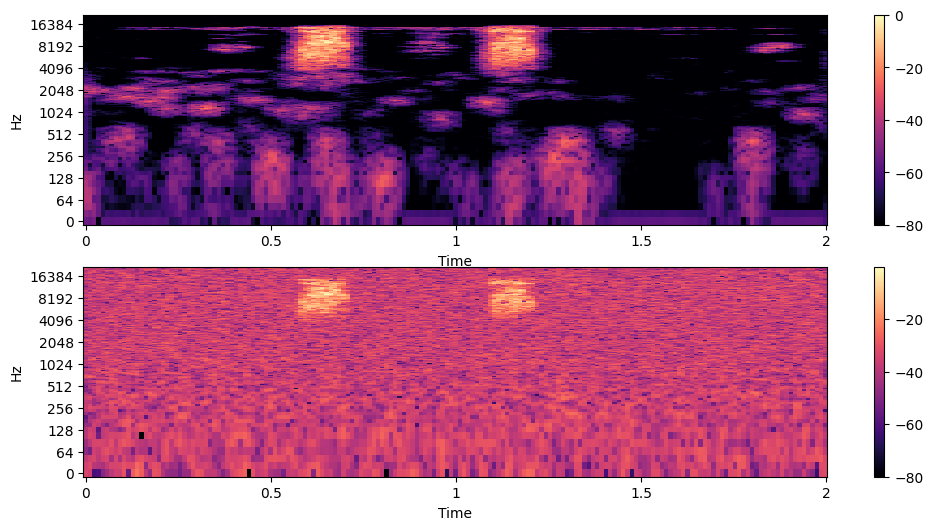

In [34]:

plot_spectro_two(d1, aug_d1, sr1)

In [21]:

augment2 = TimeStretch(min_rate=0.8, max_rate=1.25, p=1.0)
aug_d2 = augment2(samples=d1, sample_rate=sr1)

IPython.display.Audio(data=aug_d2, rate=sr1)

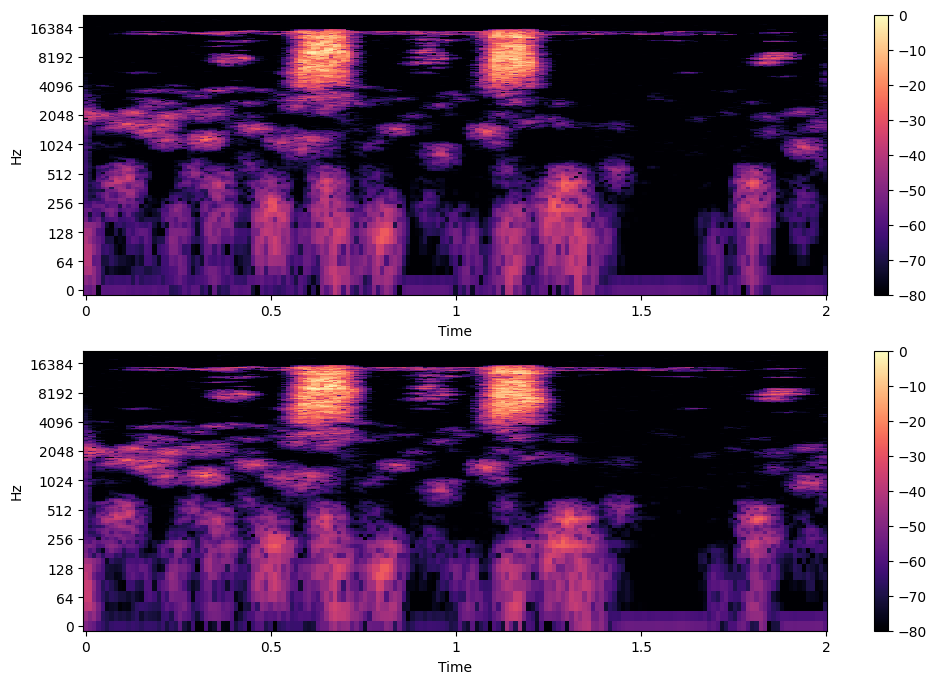

In [22]:
plot_spectro_two(d1, aug_d2, sr1)

In [23]:
augment3 = PitchShift(min_semitones=-4, max_semitones=4, p=1.0)

aug_d3 = augment3(samples=d1, sample_rate=sr1)

IPython.display.Audio(data=aug_d3, rate=sr1)

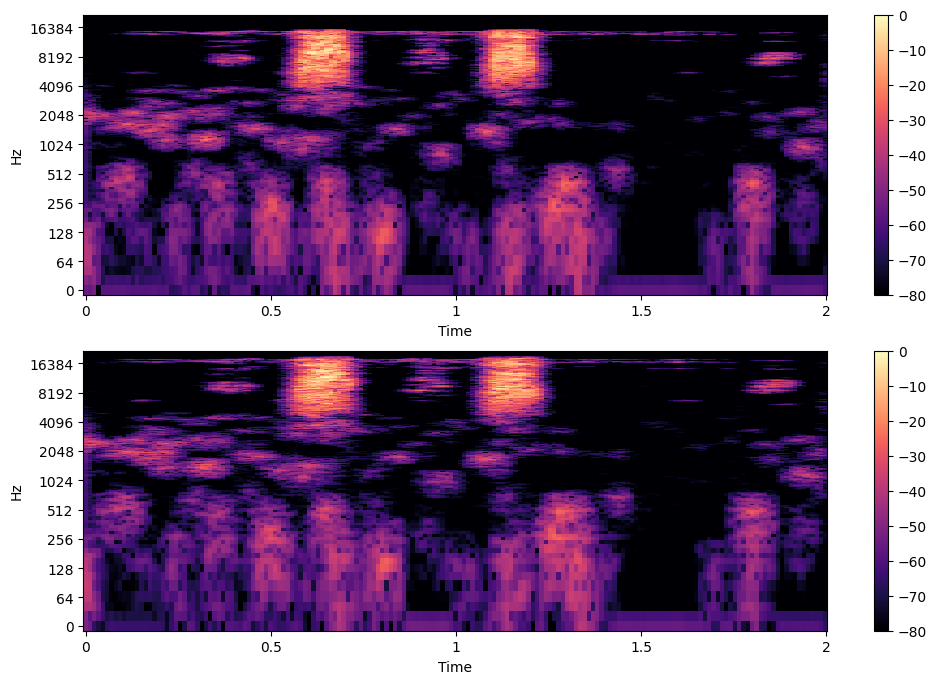

In [24]:
plot_spectro_two(d1, aug_d3, sr1)

In [27]:
augment5 = AddBackgroundNoise(
    sounds_path=BG_DIR,
    #sounds_path='../data/sound/background_sounds/mono_5s/bird_mono_44100_2.0_sliced.wav',
    min_snr_in_db=10.0,
    max_snr_in_db=30.0,
    noise_transform=PolarityInversion(),
    p=1.0
)
aug_d5 = augment5(samples=d1, sample_rate=sr1)
IPython.display.display(IPython.display.Audio(
    data=aug_d5,
    rate=sr1))

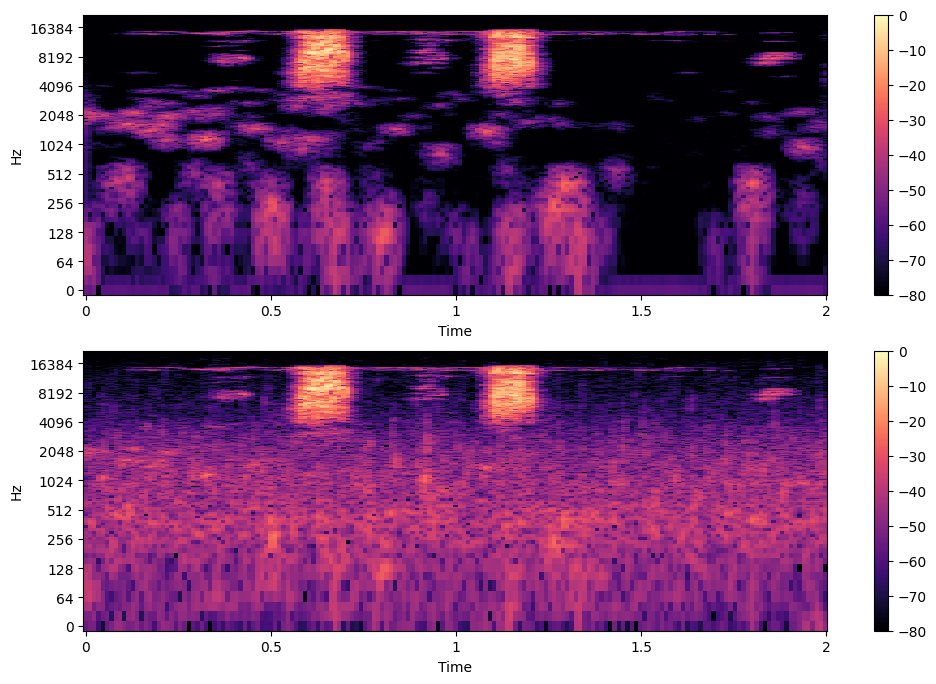

In [28]:

plot_spectro_two(d1, aug_d5, sr1)

In [29]:
augment6 = Shift(min_fraction=-0.5, max_fraction=0.5, p=0.5)
aug_d6 = augment6(samples=d1, sample_rate=sr1)
IPython.display.display(IPython.display.Audio(
    data=aug_d6,
    rate=sr1))

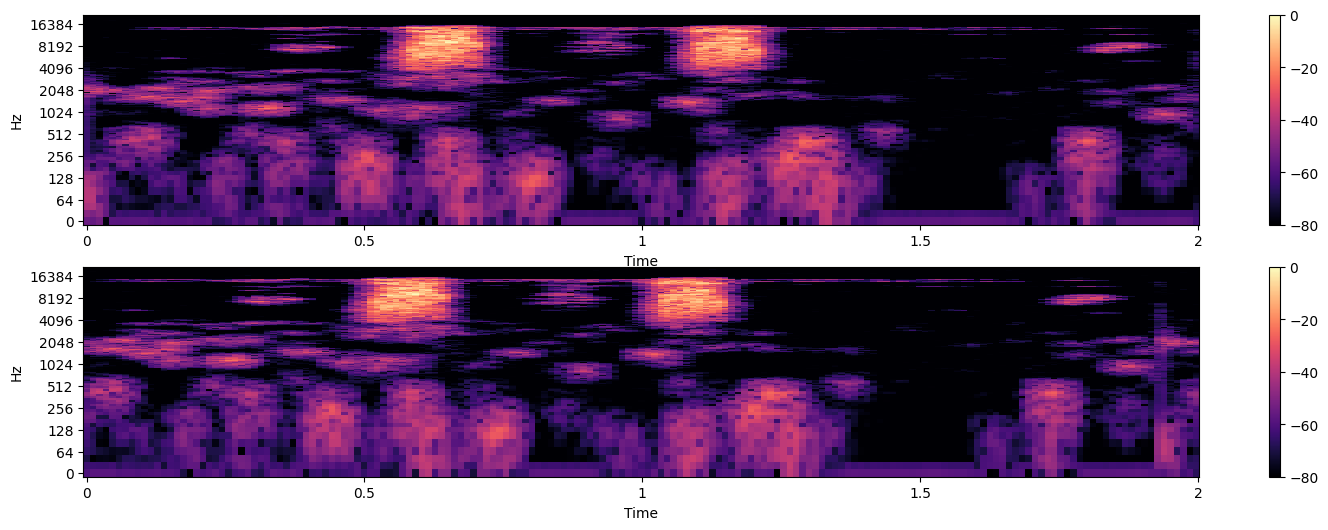

In [32]:
plot_spectro_two(d1, aug_d6, sr1)

In [40]:
in_fn = f'{DATA_DIR}/gh-4/gh-4_mono_44k_denoised_1.wav'
d7, sr7, _ = read_snd_file(in_fn, sr=None, mono=False, scale=True)

IPython.display.display(IPython.display.Audio(
    data=d7,
    rate=sr7))

load ../data/sound/grasshopper-raw-ds/gh-4/gh-4_mono_44k_denoised_1.wav sr: None offset: 0.0 duration: 60 mono: False scale: True


In [41]:
augment7 = Compose(
        [
            AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.010, p=0.3),
            TimeStretch(min_rate=0.8, max_rate=1.25, p=0.3),
            PitchShift(min_semitones=-4, max_semitones=4, p=0.3),
            AddBackgroundNoise(
                sounds_path=BG_DIR,
                # sounds_path='../data/sound/background_sounds/mono_5s/bird_mono_44100_2.0_sliced.wav',
                min_snr_in_db=10.0,
                max_snr_in_db=30.0,
                noise_transform=PolarityInversion(),
                p=0.5,
            ),
            Shift(min_fraction=-0.5, max_fraction=0.5, p=0.3),
            Reverse(p=0.3),
        ]
    )

In [45]:
da7 = augment6(samples=d7, sample_rate=sr7)
IPython.display.display(IPython.display.Audio(
    data=da7,
    rate=sr7))

In [ ]:
import soundfile as sf

sf.write('../aug.wav', da7, sr7)

